In [2]:
!ls

abalone.csv                         ds2026_ML_assignment.pdf
CO2+Emissions+Canada.csv            lab14_classification.ipynb
ds2026_ML_202500062_이서진.ipynb    my_knn.py
ds2026_ML_assignment.docx


In [3]:
# Q1
import pandas as pd

df = pd.read_csv('CO2+Emissions+Canada.csv')
df.sample(5)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
1048,VOLKSWAGEN,PASSAT,MID-SIZE,1.8,4,A6,X,9.9,6.9,8.6,33.0,198.0
4323,VOLKSWAGEN,BEETLE,COMPACT,1.8,4,AS6,X,9.7,7.2,8.5,33.0,199.0
2511,DODGE,CHALLENGER SRT HELLCAT,MID-SIZE,6.2,8,M6,Z,18.1,11.4,15.1,19.0,353.0
6077,LEXUS,IS 350 AWD,COMPACT,3.5,6,AS6,Z,12.3,9.1,10.9,26.0,254.0
1055,VOLKSWAGEN,TIGUAN,SUV - SMALL,2.0,4,A6,Z,11.7,9.5,10.7,26.0,246.0


In [4]:
# Q2
df = df.drop_duplicates()
df = df.dropna()

In [5]:
# Q3
df = df.loc[:, df.dtypes != 'str']
df.info()

<class 'pandas.DataFrame'>
Index: 6055 entries, 0 to 7384
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    6055 non-null   float64
 1   Cylinders                         6055 non-null   int64  
 2   Fuel Consumption City (L/100 km)  6055 non-null   float64
 3   Fuel Consumption Hwy (L/100 km)   6055 non-null   float64
 4   Fuel Consumption Comb (L/100 km)  6055 non-null   float64
 5   Fuel Consumption Comb (mpg)       6055 non-null   float64
 6   CO2 Emissions(g/km)               6055 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 378.4 KB


<Axes: xlabel='Cylinders', ylabel='CO2 Emissions(g/km)'>

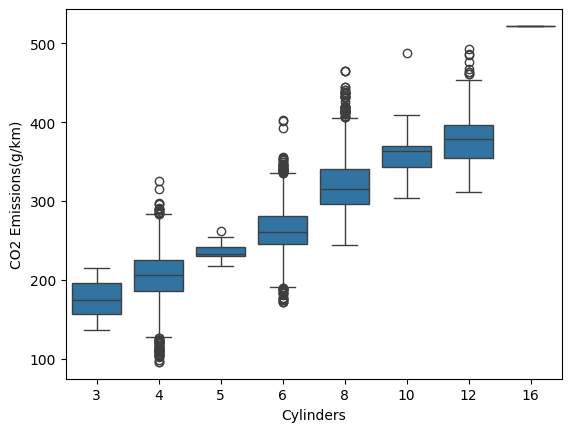

In [6]:
# Q4
import seaborn as sns
sns.boxplot(data=df, x='Cylinders', y='CO2 Emissions(g/km)')

# boxplot은 그룹별로 데이터의 사분위범위를 보여주는 것이라 두 변수의 관계를 나타내기에 적합해 보이지 않는다.
# 그런데 데이터를 살펴보니 Cylinders라는 컬럼만 연속적인 실수 데이터가 아니라 정수 데이터였고, 자동차에 들어간 실린더의 개수를 나타내는 것 같았다.
# boxplot을 찍어보니 cylinder 개수별로 그룹화해서 co2 emission을 볼 수 있었다.

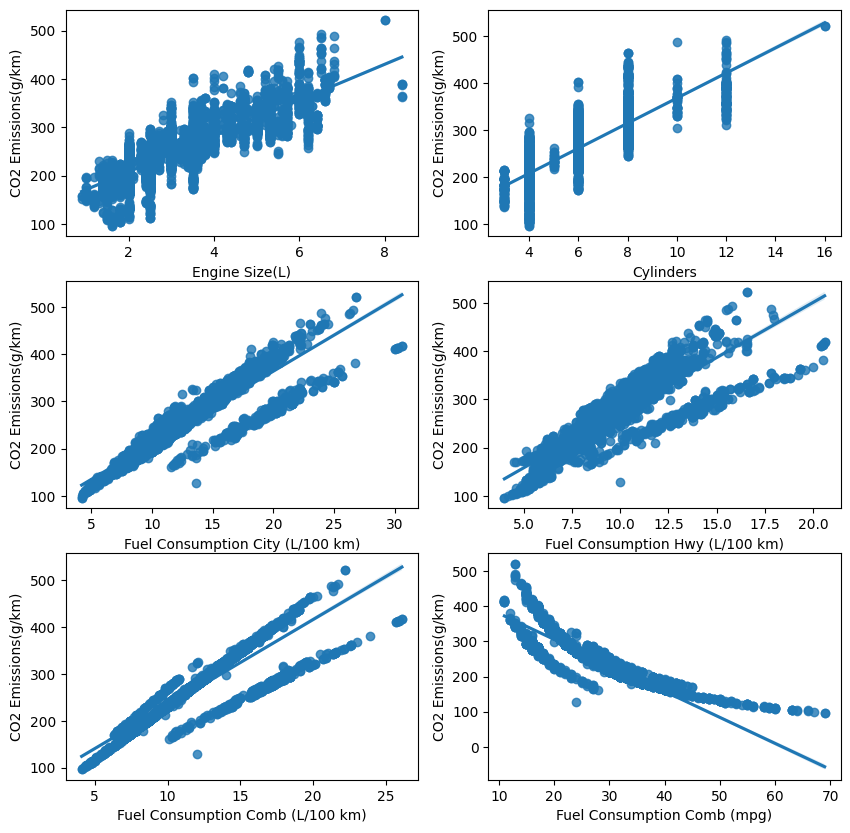

In [7]:
# Q5
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
features = df.columns[df.columns != 'CO2 Emissions(g/km)'].values.reshape(3, 2)
for i in range(3):
    for j in range(2):
        sns.regplot(ax=ax[i, j], data=df, x=features[i, j], y='CO2 Emissions(g/km)')
# regplot은 scatterplot에 regression line을 더한 것이다.
# 둘을 통해 두 feature 간의 선형적인 관계를 볼 수 있다.
# histplot과 barplot은 데이터의 그룹별 빈도수를 나타내기에 여기에 적합하지 않다.

In [8]:
# Q6
X = df['Fuel Consumption City (L/100 km)'].values.reshape(-1, 1)
Y = df['CO2 Emissions(g/km)'].values.reshape(-1, 1)

In [9]:
# Q7
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_Y = StandardScaler()

X_std = sc_X.fit_transform(X)
Y_std = sc_Y.fit_transform(Y)

In [10]:
# Q8
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y_std, test_size=0.3)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(4238, 1) (1817, 1)
(4238, 1) (1817, 1)


In [11]:
# Q9
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.91]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[65.28]


In [12]:
# Q10
from sklearn.metrics import r2_score
Y_hat = model.predict(X_test)
r2 = r2_score(Y_test, Y_hat)
print(f'r2 score={r2}')

r2 score=0.851543381114123


In [13]:
# Q11
def my_predict(X, coef, intercept):
    return intercept + coef * X

Y_hat2 = my_predict(X_test, model.coef_, model.intercept_)
r2_2 = r2_score(Y_test, Y_hat2)
print(f'model predict r2 score: {r2}')
print(f'my predict r2 score: {r2_2}')

model predict r2 score: 0.851543381114123
my predict r2 score: 0.851543381114123


In [14]:
# Q12
def my_r2_score(Y_test, Y_pred):
    Y_test_mean = Y_test.mean()
    SS_res = ((Y_test - Y_pred) ** 2).sum()
    SS_tot = ((Y_test - Y_test_mean) ** 2).sum()
    return 1 - SS_res / SS_tot

my_r2 = my_r2_score(Y_test, Y_hat)
print(f'r2 score={r2}')
print(f'my r2 score={my_r2}')

r2 score=0.851543381114123
my r2 score=0.851543381114123


In [15]:
# Q13
df2 = pd.read_csv('abalone.csv')
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [16]:
# Q14
import numpy as np
df2['Sex'] = df2['Sex'].map({'I': 0, 'F': 1, 'M':2})
df2.info()
df2['Sex']

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 293.8 KB


0       2
1       2
2       1
3       2
4       0
       ..
4172    1
4173    2
4174    2
4175    1
4176    2
Name: Sex, Length: 4177, dtype: int64

In [17]:
# Q15
X = df2[df2.columns[df2.columns != 'Sex']].values
Y = df2['Sex'].values
print(X.shape)
print(Y.shape)

(4177, 8)
(4177,)


In [18]:
# Q16
sc_X = StandardScaler()
X_std = sc_X.fit_transform(X)
# Y는 연속된 값이 아니라 그룹을 나타내기에 standardization을 진행하지 않는다.

In [19]:
# Q17
X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y, test_size=0.2)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Y_train: {Y_train.shape}, Y_test: {Y_test.shape}')

X_train: (3341, 8), X_test: (836, 8)
Y_train: (3341,), Y_test: (836,)


In [20]:
# Q18
from sklearn import svm

model = svm.SVC()
model.fit(X_train, Y_train)
Y_hat = model.predict(X_test)

In [21]:
# Q19
from sklearn.metrics import accuracy_score, confusion_matrix, \
    precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, Y_hat)
confusion = confusion_matrix(Y_test, Y_hat)
precision = precision_score(Y_test, Y_hat, average='macro')
recall = recall_score(Y_test, Y_hat, average=None)
f1 = f1_score(Y_test, Y_hat, average=None)

print(f'accuracy={accuracy}')
print(f'confusion=\n{confusion}')
print(f'precision={precision}')
print(f'recall={recall}')
print(f'f1={f1}')

accuracy=0.5705741626794258
confusion=
[[209   7  52]
 [ 32  67 161]
 [ 61  46 201]]
precision=0.5786311866141984
recall=[0.77985075 0.25769231 0.6525974 ]
f1=[0.73333333 0.35263158 0.5567867 ]


In [28]:
# Q20
def my_accuracy(Y_test, Y_pred):
    return Y_hat[Y_test == Y_pred].size / Y_pred.size

my_acc = my_accuracy(Y_test, Y_hat)
print(f'my accuracy score: {my_acc}')
print(f'accuracy score: {accuracy}')

my accuracy score: 0.5705741626794258
accuracy score: 0.5705741626794258
